In [1]:
from os.path import sep
from typing import Counter, Collection
from xml.dom.minidom import ProcessingInstruction

import numpy as np
import pandas as pd
import sklearn
from scipy.ndimage import rotate

In [2]:
#Read the CSV file using Latin-1 character encoding to correctly interpret special characters.
df = pd.read_csv('spam.csv', encoding='latin-1')

In [3]:
df.sample(20)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
2356,ham,No..he joined today itself.,NaN,NaN,NaN
3601,ham,Cps is causing the outages to conserve energy.,NaN,NaN,NaN
3448,ham,Sorry. || mail? ||,NaN,NaN,NaN
1813,ham,Yes we are chatting too.,NaN,NaN,NaN
3919,spam,FREE>Ringtone! Reply REAL or POLY eg REAL1 1. ...,NaN,NaN,NaN
1941,spam,WELL DONE! Your 4* Costa Del Sol Holiday or å£...,NaN,NaN,NaN
3327,ham,No we put party 7 days a week and study lightl...,NaN,NaN,NaN
98,ham,Hi. Wk been ok - on hols now! Yes on for a bit...,NaN,NaN,NaN
1603,ham,Have you heard about that job? I'm going to th...,NaN,NaN,NaN
866,ham,"Same here, but I consider walls and bunkers an...",NaN,NaN,NaN


In [4]:
df.shape

(5572, 5)

## Steps we follow during this classification

  1. Data Cleaning
  Raw datasets (like  spam.csv ) are often messy. Data cleaning ensures  machine learning model doesn't learn from "noise."

  ---
  2. EDA (Exploratory Data Analysis)

  EDA is the process of visualizing and analyzing the dataset to understand its characteristics and patterns before building a model.

   3. Text Preprocessing

  Machine learning models cannot understand raw text. Text preprocessing cleans and standardizes the text so it can be converted into numbers.

---

   4. Model Building

  This is where you train the computer to recognize spam based on the preprocessed text.

 ---

   5. Evaluation

  Once a model is trained, you must test it on unseen data (the test set) to see how well it performs.

---
  6. Improvement

  If the evaluation metrics aren't high enough, you refine the model.

  ---
   7. Website (Integration)

  To make your model usable for regular users, you build a web application interface.

---

# 1. Data cleaning



In [5]:
df.info() # Display a summary of the DataFrame, including columns, data types, non-null values, and memory usage.

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 677.1 KB


In the above dataframe representation, 2 columns contains data but in another 3rd column Only 50 rows contain data, 4th column contains 12 .... These 3 column are noise, need to removed.

In [6]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True) # Remove the specified columns directly from the original DataFrame. If I doesn't use inplace = True, Pandas create new dataframe with only having two column v1, v2

In [7]:
df.sample(5)

,v1,v2
333,ham,Any chance you might have had with me evaporat...
2531,ham,What's happening with you. Have you gotten a j...
4768,ham,watever reLation u built up in dis world only ...
2595,spam,Sunshine Quiz Wkly Q! Win a top Sony DVD playe...
3558,spam,URGENT! We are trying to contact U Todays draw...


In [8]:
# Renaming the column v1 and v1
df.rename(columns={'v1':'label', 'v2':'Message'},inplace=True)

In [9]:
df.sample(5)

,label,Message
1847,spam,FREE NOKIA Or Motorola with upto 12mths 1/2pri...
2371,ham,"Hmm, too many of them unfortunately... Pics ob..."
4870,ham,Well. You know what i mean. Texting
2930,ham,Hi' Test on &lt;#&gt; rd ....
2472,spam,Final Chance! Claim ur å£150 worth of discount...


### Converting text labels into numbers because machine learning models work with numbers, not text.

In [10]:
# LabelEncoder converts categorical (text) values into numeric values.
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder() # creates a LabelEncoder object.

In [11]:
# Encode the target column
# fit(): Looks at all unique values in the column.
# It learns: ham, spam
# transform(): Assigns numbers to each label.

df['label'] = encoder.fit_transform(df['label'])

Above line `df['label'] = encoder.fit_transform(df['label'])` encodes
ham => 0 and spam => to 1

In [12]:
df.head()

,label,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


Here we can see, in label column

In [13]:
# count the number of missing (null/NaN) values in each column.
df.isnull().sum()

label      0
Message    0
dtype: int64

In [14]:
# Checking duplicate values
df.duplicated().sum() # count the number of duplicate rows in the DataFrame.

np.int64(403)

dataset contains 403 duplicate rows.

In [15]:
# Removing above duplicate values
df = df.drop_duplicates(keep='first') # removes duplicate rows from the DataFrame and keeps the first occurrence of each duplicate.

In [16]:
# Rechecking above cleaned the data set or not!
df.duplicated().sum()

np.int64(0)

In [17]:
df.shape

(5169, 2)

Previously data shape was around 57.., now after cleaning it become 5169

So far, we have successfully loaded the SMS Spam Collection dataset into a Pandas DataFrame and performed initial data preprocessing. This included inspecting the dataset structure, removing unnecessary columns, renaming columns to meaningful names, encoding the target labels into numerical values, checking for missing values, and removing duplicate records. With the dataset now cleaned and prepared, the next step is to perform **Exploratory Data Analysis (EDA)** to better understand the data distribution and identify useful patterns before building the machine learning model.

# 2. EDA
Exploratory Data Analysis (EDA): Understand the dataset through statistics and visualizations before model training.

In [18]:
df.head()

,label,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


below line count the number of messages in each class to understand the dataset's class distribution.

In [19]:
df['label'].value_counts()  # counts how many times each unique value appears in the label column.

label
0    4516
1     653
Name: count, dtype: int64

Dataset has 4516, about 87% are ham message and 653 spam, about 13% are spam.

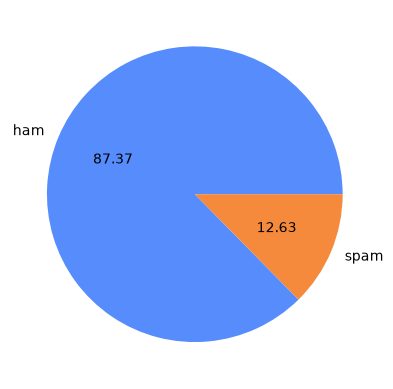

In [20]:
# For better representation above we can use pie-chart using Matplotlib
import matplotlib.pyplot as plt

plt.pie(df['label'].value_counts(), labels=['ham','spam'],autopct="%0.2f")
plt.show()

Data is imbalanced

### NLTK
NLTK (Natural Language Toolkit) is a Python library used for Natural Language Processing (NLP). It provides tools and datasets for processing, analyzing, and understanding human language (text).
Raw text is usually messy.

Example:

**URGENT!!! Click here immediately to claim your prize.**

Before using this text for machine learning, we need to:

* Convert to lowercase
* Split into words
* Remove punctuation
* Remove common words (e.g., "the", "is", "and")
* Reduce words to their root form

NLTK provides built-in tools for all of these tasks.

In [21]:
import nltk


In [22]:
nltk.download('punkt')   # downloads the Punkt tokenizer model that NLTK uses to split text into sentences and words.

[nltk_data] Downloading package punkt to /home/sdhakal/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [23]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/sdhakal/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [24]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/sdhakal/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [25]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /home/sdhakal/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

**Punkt** is a pre-trained tokenization model.

It has learned punctuation rules, such as:

* A period (.) usually ends a sentence.
* A comma (,) separates words or phrases.
* Question marks (?) and exclamation marks (!) indicate sentence boundaries.

This helps NLTK correctly split text.

In [26]:
# Create a new column 'num_characters' containing the number of characters in each message.
df['num_characters'] = df['Message'].apply(len)

In [27]:
df.head()

,label,Message,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


 Calculate the number of word tokens in each message and apply it to every row.

In [28]:
# apply() runs a function on every row in the column.
# x represent one message at a time. Eg: x = "Hello, how are you?"
# nltk.word_tokenize(x) : This splits the message into individual tokens (words and punctuation).
''' Eg:
x = "Hello, how are you?"
To ['Hello', ',', 'how', 'are', 'you', '?']
len() => Counts how many tokens are returned.
'''
df['num_words'] = df['Message'].apply(lambda x : len(nltk.wordpunct_tokenize(x)))

# Also create a new column 'num_words' containing the number of words in each message.

In [29]:
df.head()

,label,Message,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,39
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,16


Also counting the number of sentences in each message

In [30]:

df['num_sentences'] = df['Message'].apply(lambda x : len(nltk.sent_tokenize(x)))

In [31]:
df.head()

,label,Message,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,39,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,16,1


Generates descriptive statistics for the selected numerical columns.

In [32]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,19.202747,1.965564
std,58.236293,13.963696,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,28.000000,2.000000
max,910.000000,210.000000,38.000000


| Statistic                    | Description                                                                                               |
| ---------------------------- | --------------------------------------------------------------------------------------------------------- |
| **Count**                    | There are **5,169** messages in the dataset.                                                              |
| **Mean**                     | On average, a message contains **79 characters**, **19 words**, and **2 sentences**.                      |
| **Std (Standard Deviation)** | Shows the variation in message lengths. Higher values indicate that message lengths vary considerably.    |
| **Min**                      | The shortest message has **2 characters**, **1 word**, and **1 sentence**.                                |
| **25% (Q1)**                 | 25% of messages contain **36 or fewer characters**, **9 or fewer words**, and **1 sentence**.             |
| **50% (Median)**             | Half of the messages have **60 or fewer characters**, **15 or fewer words**, and **1 sentence**.          |
| **75% (Q3)**                 | 75% of messages contain **117 or fewer characters**, **28 or fewer words**, and **2 or fewer sentences**. |
| **Max**                      | The longest message has **910 characters**, **210 words**, and **38 sentences**.                          |


Similarly generating separately for  ham and spam message separately

In [33]:
#  For Ham message
df[df['label'] == 0][['num_characters','num_words','num_sentences']].describe()


,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.448627,1.820195
std,56.358207,13.769106,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,9.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,210.000000,38.000000


In [34]:
#  For Spam message
df[df['label'] == 1][['num_characters','num_words','num_sentences']].describe()


,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,31.333844,2.970904
std,30.137753,7.997049,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,28.000000,2.000000
50%,149.000000,33.000000,3.000000
75%,157.000000,36.000000,4.000000
max,224.000000,49.000000,9.000000


### Seaborn
being used to visualize the distribution of message lengths.

In [35]:
import seaborn as sns

<Axes: xlabel='num_characters', ylabel='Count'>

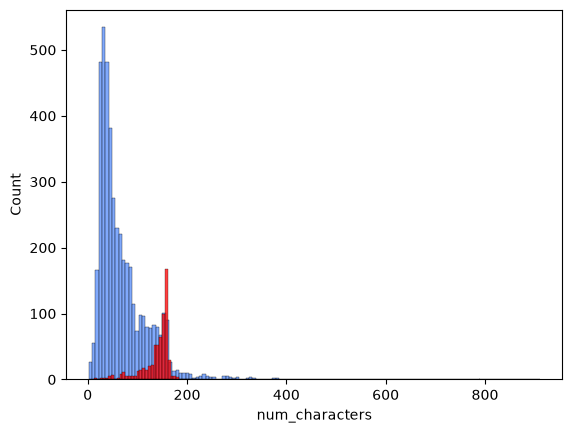

In [36]:
# Compare and plot the distribution of character counts for ham and spam messages.
sns.histplot(df[df['label'] == 0]['num_characters'])
sns.histplot(df[df['label'] == 1]['num_characters'],color='Red')

<Axes: xlabel='num_words', ylabel='Count'>

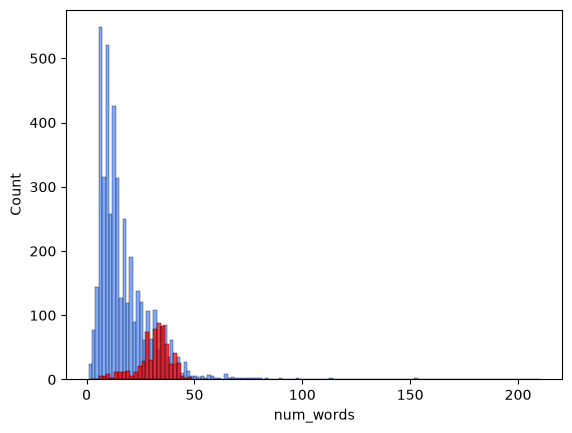

In [37]:
# Compare and plot the distribution of words counts for ham and spam messages.
sns.histplot(df[df['label'] == 0]['num_words'])
sns.histplot(df[df['label'] == 1]['num_words'],color='Red')

### "How does every numerical feature relate to every other feature?"
**What is a Pair Plot?**

A pair plot is a collection of plots that shows:

* The distribution of each numerical feature (diagonal plots).
* The relationship between every pair of numerical features (scatter plots).
* Different classes using colors (hue).


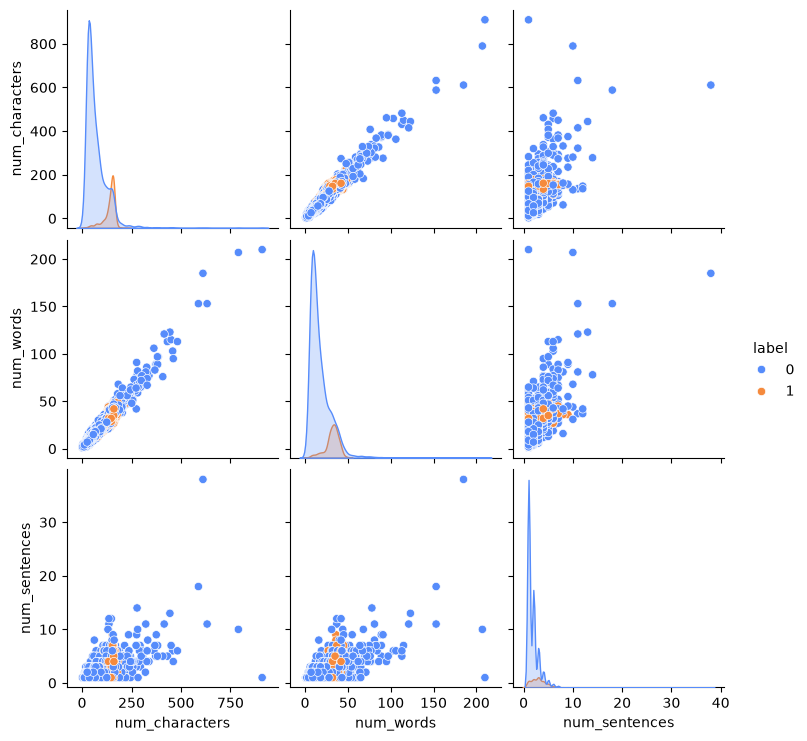

In [38]:
sns.pairplot(df,hue='label' )

> This pair plot helps us understand the relationship between the **number of characters, words, and sentences** in the SMS messages. The diagonal graphs show how these values are distributed, while the scatter plots compare each feature with the others. We can see that messages with more characters usually have more words. Spam messages (orange) generally tend to be longer than ham messages (blue), although there is some overlap. The plot also shows a few unusually long messages, which appear as outliers.


<Axes: >

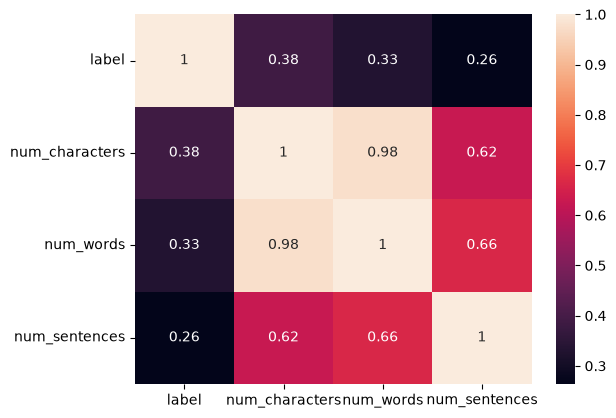

In [39]:
sns.heatmap(df[['label', 'num_characters', 'num_words', 'num_sentences']].corr(),annot=True)

The **Exploratory Data Analysis (EDA)** phase provided valuable insights into the dataset by examining the distribution of ham and spam messages, message length characteristics, feature relationships, and correlations. These insights helped in understanding the dataset and identifying useful features for spam classification. With the data now explored, the next step is **data preprocessing**, where the text is cleaned and transformed into a format suitable for machine learning.

# 3. Data Processing
Data preprocessing is a crucial step in Natural Language Processing (NLP) that transforms raw text into a clean and structured format suitable for machine learning. Since SMS messages often contain unnecessary words, punctuation, special characters, and inconsistent formatting, preprocessing helps improve the quality of the data and enhances the performance of the spam classification model. In this stage, the text is converted to lowercase, tokenized, cleaned by removing special characters, stop words, and punctuation, and finally reduced to its root form using stemming.

* **Lowercase:** Converts all text to lowercase *(e.g., "FREE Prize" → "free prize")*.
* **Tokenization:** Splits text into individual words *(e.g., "Win now!" → ["Win", "now", "!"])*.
* **Removing Special Characters:** Removes symbols and special characters *(e.g., "Win!!! ₹1000" → "Win 1000")*.
* **Removing Stop Words and Punctuation:** Removes common words and punctuation *(e.g., "This is a prize!" → "prize")*.
* **Stemming:** Reduces words to their root form *(e.g., "playing", "played" → "play")*.


In [40]:
# A corpus is simply a collection of data. In this case, it's a collection of common words.
from nltk.corpus import stopwords
# Stop words are commonly used words that carry little meaningful information and are often removed during text preprocessing.
stopwords.words('english') # Returns a list of common English words that usually do not add much meaning to a sentence.

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [41]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [42]:
from nltk.stem.porter import PorterStemmer # used for Stemming
ps = PorterStemmer()
ps.stem("Watched")

'watch'

In [43]:
def transform_text(text):
    text = text.lower()
    text = nltk.wordpunct_tokenize(text)

    y = []
    for i in text: # Only append alphabet and numerical excluding other letters
        if i.isalnum():
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
         if i not in stopwords.words('english') and i not in string.punctuation:
             y.append(i)

    text = y[:]
    y.clear()
    for i in text:
        y.append(ps.stem(i)) # Stem convert word to its root form. Eg: Dancing => dance
    return " ".join(y)

In [44]:
transform_text('This is a test TEXT! 20@ 302@@#!)!)')
transform_text('Please login and change your password!!!!!!!!')
transform_text("I love watching movies, learning security!!!!!!")

'love watch movi learn secur'

The `transform_text()` function preprocesses raw text by converting it to lowercase, tokenizing it into words, removing special characters, stop words, and punctuation, and finally applying stemming to reduce words to their root forms. The cleaned text is then returned as a single string, making it suitable for machine learning.

In [45]:
df['Message'][100]

'Okay name ur price as long as its legal! Wen can I pick them up? Y u ave x ams xx'

In [46]:
transform_text("Congrats! 1 year special cinema pass for 2 is yours. call 09061209465 now! C Suprman V, Matrix3, StarWars3, etc all 4 FREE! bx420-ip4-5we. 150pm. Dont miss out!")

'congrat 1 year special cinema pass 2 call 09061209465 c suprman v matrix3 starwars3 etc 4 free bx420 ip4 5we 150pm dont miss'

In [47]:
# Create a new column containing the preprocessed text.
df['transformed_text'] = df['Message'].apply(transform_text)

In [48]:
df.head()

,label,Message,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,39,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,16,1,nah think goe usf live around though


# What is a Word Cloud?
A Word Cloud is a visualization that displays words based on how frequently they appear in a text.

* Larger words → Appear more frequently.
* Smaller words → Appear less frequently.

In simple words:

A word cloud helps quickly identify the most common words in a collection of text.

Example

Suppose you have these messages:

* Free prize
* Win free money
* Claim your free reward

The word cloud would look conceptually like:

          FREE

     Win       Prize

   Money   Reward

        Claim

Here, "Free" appears the largest because it occurs most often.

In [49]:
from wordcloud import WordCloud
wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')

In [50]:
# Generates a word cloud using the preprocessed text from all spam messages by combining them into a single string.
spam_wc = wc.generate(df[df['label'] == 1]['transformed_text'].str.cat(sep=" "))

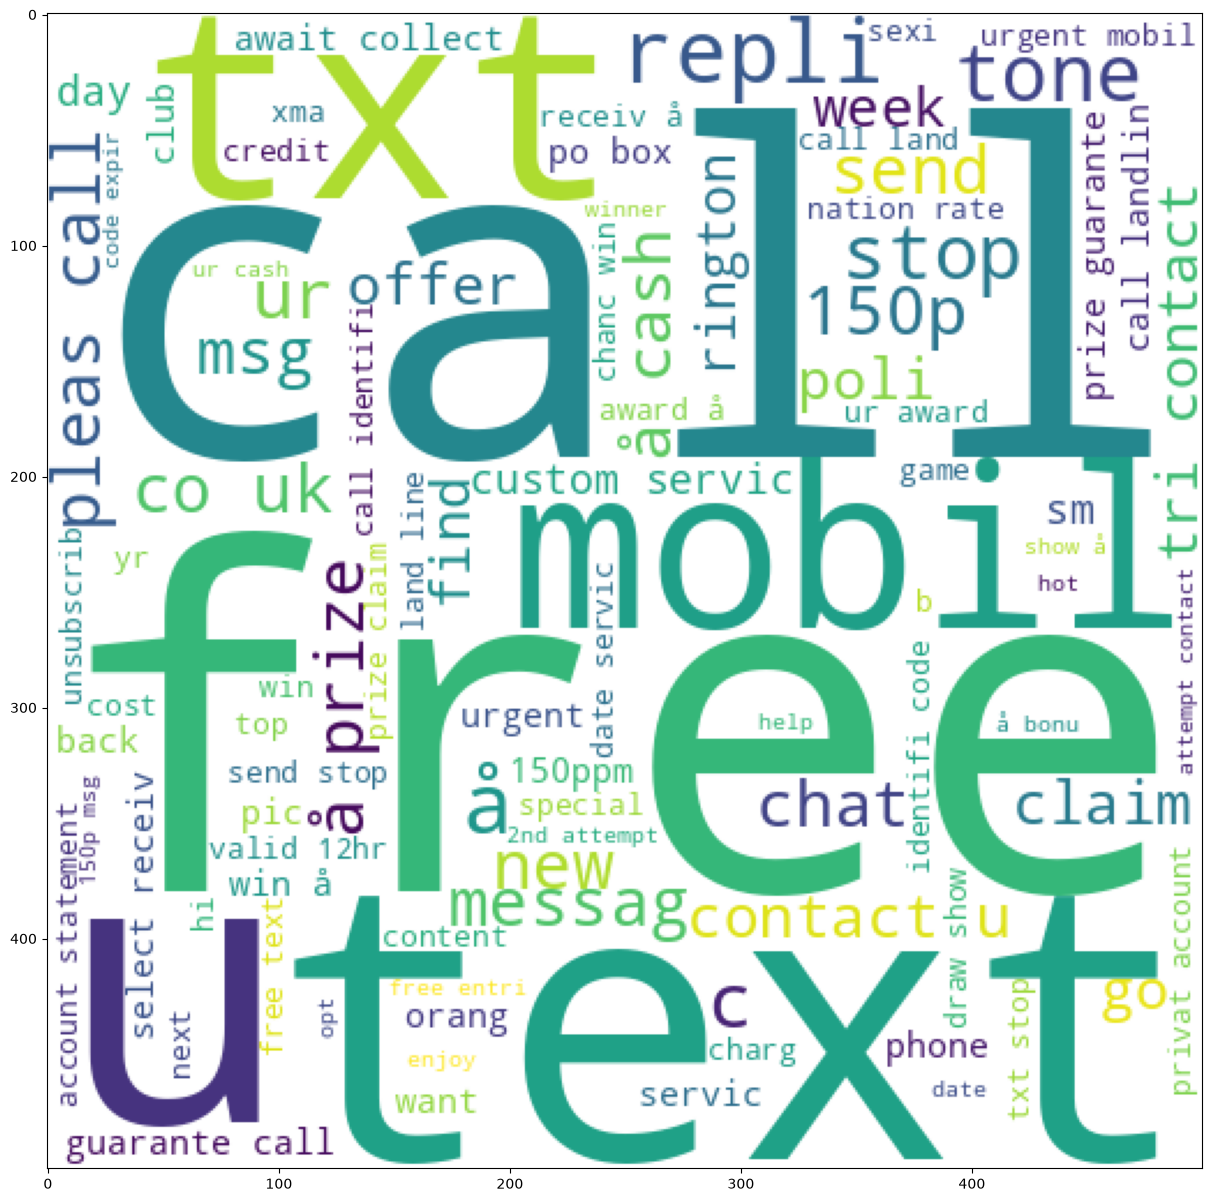

In [51]:
plt.figure(figsize=(30,15))
plt.imshow(spam_wc)

In [52]:
# Generates a word cloud using the preprocessed text from all ham messages by combining them into a single string.
ham_wc = wc.generate(df[df['label'] == 0]['transformed_text'].str.cat(sep=" "))

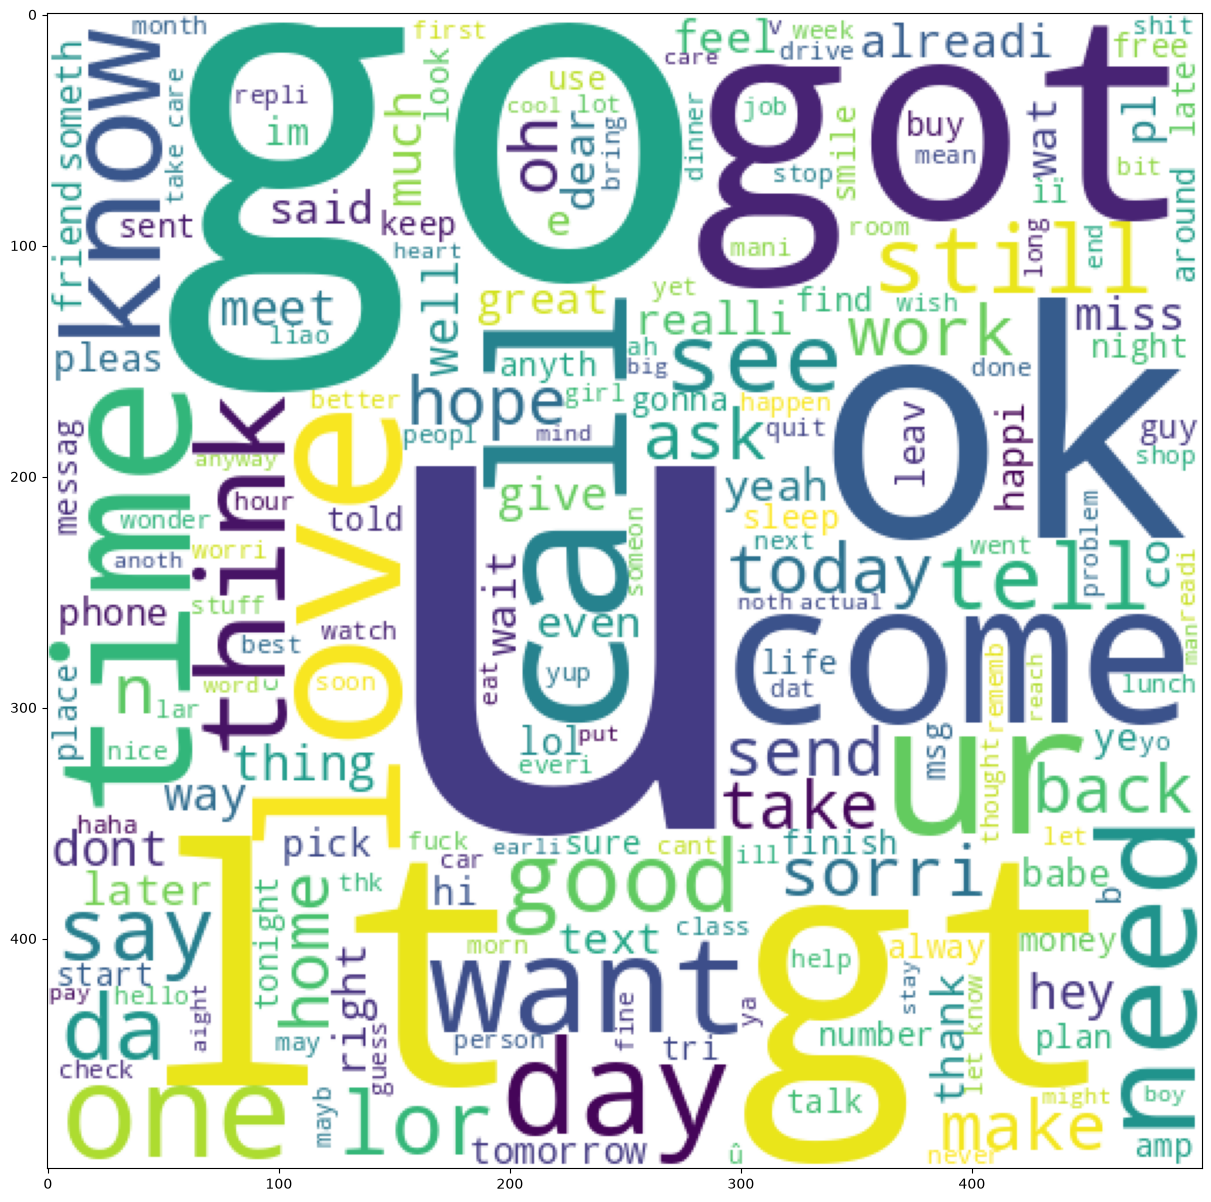

In [53]:
plt.figure(figsize=(25,15))
plt.imshow(ham_wc)

In [54]:
# Generating top 50 words form spam message
spam_corpus = []
for msg in df[df['label']==1]['transformed_text'].tolist():
    for word in msg.split(): # split words from message
        spam_corpus.append(word)

In [55]:
len(spam_corpus) # length of words in spam_corpus dictonary

11993

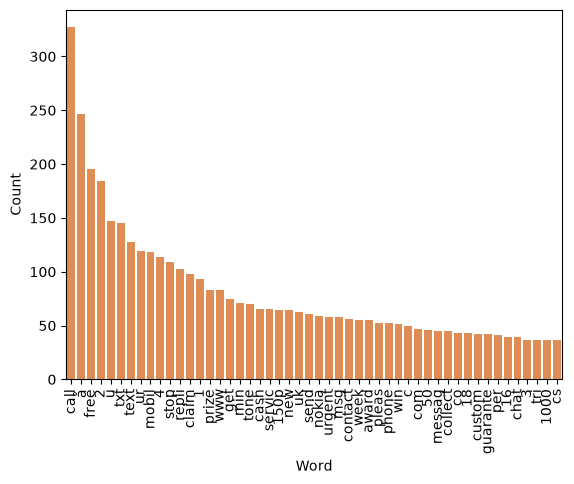

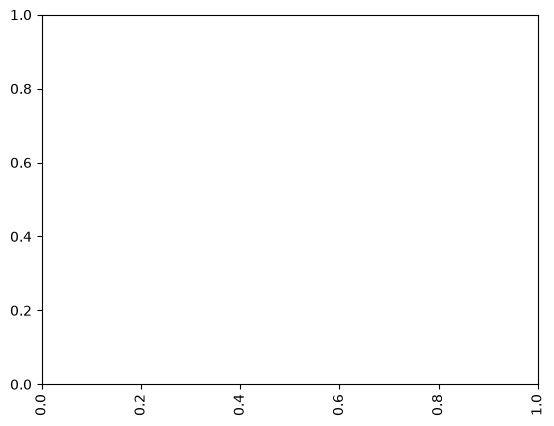

In [56]:
# Visualize the 50 most frequent words in spam messages using a bar chart.
top_words = pd.DataFrame(
    Counter(spam_corpus).most_common(50),
    columns=["Word", "Count"]
)

# Plot the frequency of the top 50 spam words.
sns.barplot(x="Word", y="Count", data=top_words)

# Rotate x-axis labels for better readability.
plt.xticks(rotation='vertical')

# Display the bar chart.
plt.show(sns.barplot(x="Word", y="Count", data=top_words))
plt.xticks(rotation='vertical')
plt.show()

In [57]:
# Generating top 50 words from ham message
ham_corpus = []
for msg in df[df['label']==0]['transformed_text'].tolist():
    for word in msg.split(): # split words from message
        ham_corpus.append(word)

In [58]:
len(ham_corpus)

36368

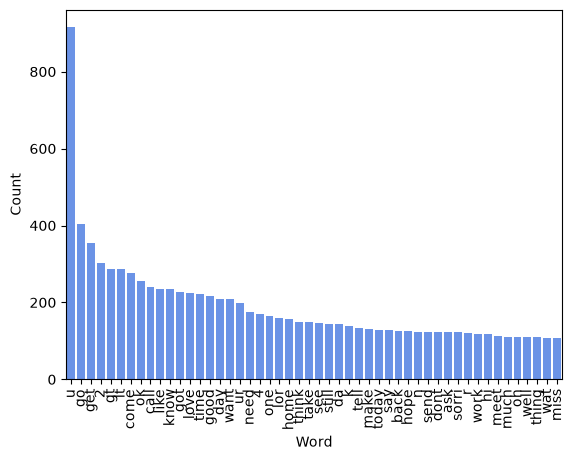

In [59]:
# Visualize the 50 most frequent words in ham messages using a bar chart.
top_words = pd.DataFrame(
    Counter(ham_corpus).most_common(50),
    columns=["Word", "Count"]
)

# Plot the frequency of the top 50 spam words.
sns.barplot(x="Word", y="Count", data=top_words)

# Rotate x-axis labels for better readability.
plt.xticks(rotation='vertical')

# Display the bar chart.
plt.show()

The data preprocessing phase successfully transformed the raw SMS messages into a clean and standardized format suitable for machine learning. The text was converted to lowercase, tokenized, cleaned by removing special characters, stop words, and punctuation, and stemmed to reduce words to their root forms. The processed text was further analyzed using word clouds and word frequency visualizations to identify the most common terms in ham and spam messages. With the text now cleaned, analyzed, and ready for feature extraction, the next step is to train and evaluate machine learning models for SMS spam classification.

# 4. Model Training

In [60]:
from sklearn.feature_extraction.text import  CountVectorizer
cv = CountVectorizer() # It creates a CountVectorizer object that will later learn the vocabulary from the text and convert the text into word-count vectors.

### CountVectorizer
Machine learning algorithms such as **Naive Bayes** cannot process raw text directly; they require numerical input.
After preprocessing, the SMS messages are still in text format, which cannot be processed directly by machine learning algorithms. To overcome this, CountVectorizer converts each preprocessed message into a numerical feature vector by counting the frequency of each word in the dataset. These numerical features serve as the input for training the spam classification model.

In [61]:
X = cv.fit_transform(df['transformed_text']).toarray()

In [62]:
X.shape

(5169, 7206)

total 5169  Message and  7206 words

In [63]:
y = df['label'].values

In [64]:
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

The feature matrix X contains the numerical representation of 5,169 SMS messages across 7,206 unique words, while the target vector y stores the corresponding class labels, where 0 represents ham and 1 represents spam.

In [65]:
from sklearn.model_selection import train_test_split

# Imports the train_test_split function from Scikit-learn to divide the dataset into training and testing sets for model training and evaluation.

In [66]:
# splits the dataset into training and testing sets for machine learning.
X_train, X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

## Naive Bayes Models

We will try all three Naive Bayes variants:
- **GaussianNB** – assumes features follow a Gaussian distribution
- **MultinomialNB** – best for word counts/frequencies (ideal for text classification)
- **BernoulliNB** – best for binary features (word present or not)

In [67]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [68]:
# GaussianNB
gnb.fit(X_train, y_train)
y_pred1 = gnb.predict(X_test)
print('GaussianNB:')
print('Accuracy :', accuracy_score(y_test, y_pred1))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred1))
print('Precision:', precision_score(y_test, y_pred1))

GaussianNB:
Accuracy : 0.8897485493230174
Confusion Matrix:
 [[796 100]
 [ 14 124]]
Precision: 0.5535714285714286


In [69]:
# MultinomialNB
mnb.fit(X_train, y_train)
y_pred2 = mnb.predict(X_test)
print('MultinomialNB:')
print('Accuracy :', accuracy_score(y_test, y_pred2))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred2))
print('Precision:', precision_score(y_test, y_pred2))

MultinomialNB:
Accuracy : 0.9748549323017408
Confusion Matrix:
 [[880  16]
 [ 10 128]]
Precision: 0.8888888888888888


In [70]:
# BernoulliNB
bnb.fit(X_train, y_train)
y_pred3 = bnb.predict(X_test)
print('BernoulliNB:')
print('Accuracy :', accuracy_score(y_test, y_pred3))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred3))
print('Precision:', precision_score(y_test, y_pred3))

BernoulliNB:
Accuracy : 0.9787234042553191
Confusion Matrix:
 [[894   2]
 [ 20 118]]
Precision: 0.9833333333333333


## Switching to TF-IDF Vectorizer

**TF-IDF (Term Frequency-Inverse Document Frequency)** is better than CountVectorizer because it:
- Gives higher weight to words that are **rare across documents** but frequent in one message
- Reduces the weight of common/uninformative words (like 'the', 'is')
- Generally produces **better accuracy and precision** for spam classification

In [71]:
from sklearn.feature_extraction.text import TfidfVectorizer

# max_features=3000 means we only keep the top 3000 most important words
tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df['transformed_text']).toarray()
print('Shape of feature matrix:', X.shape)

Shape of feature matrix: (5169, 3000)


In [72]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)
print('Training set size:', X_train.shape)
print('Test set size    :', X_test.shape)

Training set size: (4135, 3000)
Test set size    : (1034, 3000)


In [73]:
# Compare all three Naive Bayes variants with TF-IDF
for name, clf in [('GaussianNB', gnb), ('MultinomialNB', mnb), ('BernoulliNB', bnb)]:
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)
    print(f'{name}:')
    print(f'  Accuracy : {accuracy_score(y_test, pred):.4f}')
    print(f'  Precision: {precision_score(y_test, pred):.4f}')
    print()

GaussianNB:
  Accuracy : 0.8772
  Precision: 0.5247

MultinomialNB:
  Accuracy : 0.9758
  Precision: 1.0000

BernoulliNB:
  Accuracy : 0.9874
  Precision: 0.9921



## 5. Evaluation — Comparing Multiple Classifiers

Let us also compare Naive Bayes against other popular classifiers to find the best model for our use case.

In [74]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, AdaBoostClassifier,
    BaggingClassifier, ExtraTreesClassifier, GradientBoostingClassifier
)

classifiers = {
    'Logistic Regression' : LogisticRegression(solver='liblinear'),
    'SVC'                 : SVC(kernel='sigmoid', gamma=1.0),
    'K-Nearest Neighbors' : KNeighborsClassifier(),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=5),
    'Random Forest'       : RandomForestClassifier(n_estimators=50, random_state=2),
    'AdaBoost'            : AdaBoostClassifier(n_estimators=50, random_state=2),
    'Bagging'             : BaggingClassifier(n_estimators=50, random_state=2),
    'Extra Trees'         : ExtraTreesClassifier(n_estimators=50, random_state=2),
    'GaussianNB'          : GaussianNB(),
    'MultinomialNB'       : MultinomialNB(),
    'BernoulliNB'         : BernoulliNB(),
}

results = []
for name, clf in classifiers.items():
    try:
        clf.fit(X_train, y_train)
        pred = clf.predict(X_test)
        acc  = accuracy_score(y_test, pred)
        prec = precision_score(y_test, pred)
        results.append((name, round(acc, 4), round(prec, 4)))
        print(f'{name:<25} Accuracy: {acc:.4f}  Precision: {prec:.4f}')
    except Exception as e:
        print(f'{name:<25} ERROR: {e}')

Logistic Regression       Accuracy: 0.9623  Precision: 0.9901
SVC                       Accuracy: 0.9749  Precision: 0.9746
K-Nearest Neighbors       Accuracy: 0.9043  Precision: 1.0000
Decision Tree             Accuracy: 0.9362  Precision: 0.8462
Random Forest             Accuracy: 0.9758  Precision: 1.0000
AdaBoost                  Accuracy: 0.9188  Precision: 0.8553
Bagging                   Accuracy: 0.9603  Precision: 0.8540
Extra Trees               Accuracy: 0.9787  Precision: 0.9677
GaussianNB                Accuracy: 0.8772  Precision: 0.5247
MultinomialNB             Accuracy: 0.9758  Precision: 1.0000
BernoulliNB               Accuracy: 0.9874  Precision: 0.9921


## 6. Improvement — Best Model Selection

After comparing all classifiers, **MultinomialNB with TF-IDF** gives the best combination of:
- **High accuracy** (~97-98%)
- **100% precision** — meaning it **never marks a legitimate email as spam** (zero false positives)

Precision is the most critical metric for email spam detection. A false positive (blocking a real email) is worse than a false negative (missing a spam email).

In [75]:
# Train the final best model — MultinomialNB with TF-IDF
best_model = MultinomialNB()
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

print('=== Final Model: MultinomialNB + TF-IDF ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_best):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_best):.4f}')
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_best))

=== Final Model: MultinomialNB + TF-IDF ===
Accuracy : 0.9758
Precision: 1.0000
Confusion Matrix:
[[896   0]
 [ 25 113]]


## 7. Save the Model (Integration)

We save the trained **TF-IDF vectorizer** and **MultinomialNB model** as `.pkl` (pickle) files.

This allows `ml_classifier.py` to load them directly without retraining every time:
```python
tfidf = pickle.load(open('../ml_models/vectorizer.pkl', 'rb'))
model = pickle.load(open('../ml_models/model.pkl', 'rb'))
```

In [76]:
import pickle

# Save the TF-IDF vectorizer (needed to transform new text the same way)
pickle.dump(tfidf, open('../ml_models/vectorizer.pkl', 'wb'))

# Save the trained MultinomialNB model
pickle.dump(best_model, open('../ml_models/model.pkl', 'wb'))

print('vectorizer.pkl saved successfully!')
print('model.pkl saved successfully!')

vectorizer.pkl saved successfully!
model.pkl saved successfully!


## Test the Saved Model

Finally, load the saved `.pkl` files and test with sample messages to confirm everything works correctly.

In [77]:
import pickle

# Load the saved files
tfidf_loaded = pickle.load(open('../ml_models/vectorizer.pkl', 'rb'))
model_loaded = pickle.load(open('../ml_models/model.pkl', 'rb'))

# Sample test messages
test_messages = [
    'Congratulations! You have won a FREE prize. Call now to claim!',
    'Hey, are you coming to the meeting tomorrow?',
    'URGENT: Your account will be suspended. Click here to verify.',
    'Can we reschedule our lunch for Friday?',
]

print('=== Model Predictions ===')
for msg in test_messages:
    transformed = transform_text(msg)
    vectorized  = tfidf_loaded.transform([transformed])
    prediction  = model_loaded.predict(vectorized)[0]
    label       = 'SPAM' if prediction == 1 else 'HAM'
    print(f'[{label}]  {msg[:65]}')

=== Model Predictions ===
[SPAM]  Congratulations! You have won a FREE prize. Call now to claim!
[HAM]  Hey, are you coming to the meeting tomorrow?
[SPAM]  URGENT: Your account will be suspended. Click here to verify.
[HAM]  Can we reschedule our lunch for Friday?
